In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sleeve_model import SleeveCNNAttentionImproved

In [2]:
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / 'outputs'
CONFIG_PATH = OUTPUT_DIR / 'config.json'
MODEL_PATH = OUTPUT_DIR / 'best_model.pt'

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f'Missing config: {CONFIG_PATH}')
if not MODEL_PATH.exists():
    raise FileNotFoundError(f'Missing checkpoint: {MODEL_PATH}')

with open(CONFIG_PATH, 'r') as f:
    config = json.load(f)

config

{'model': {'architecture': 'SleeveCNNAttentionImproved',
  'n_ch': 128,
  'window_size': 400,
  'n_joints': 14,
  'hidden': 256,
  'n_attn': 4,
  'n_heads': 4,
  'parameters': 4408930},
 'training': {'batch_size': 256,
  'epochs': 150,
  'lr': 0.0005,
  'eta_min': 3e-05,
  'warmup_epochs': 5,
  'weight_decay': 0.0003,
  'dropout': 0.15,
  'optimizer': 'AdamW',
  'scheduler': 'CosineAnnealingLR',
  'loss': 'SmoothL1Loss(beta=0.5)',
  'grad_clip': 1.0,
  'seed': 42},
 'data': {'train_samples': 5734,
  'val_samples': 1433,
  'emg_shape': [5734, 128, 400],
  'paper_replication': False,
  'emg_transform': 'log1p',
  'input_mode': 'raw',
  'rms_subframes': 25,
  'input_scaler': 'standard',
  'target_scaler': 'standard',
  'train_target_lag': 1,
  'enable_lag_sweep': False,
  'lag_sweep_max': 30,
  'checkpoint_selection': 'r2'},
 'device': 'cuda'}

In [3]:
model_cfg = config['model']
model = SleeveCNNAttentionImproved(
    n_ch=int(model_cfg['n_ch']),
    window_size=int(model_cfg['window_size']),
    n_joints=int(model_cfg['n_joints']),
    hidden=int(model_cfg['hidden']),
    n_attn=int(model_cfg['n_attn']),
    n_heads=int(model_cfg['n_heads']),
    dropout=float(config['training']['dropout']),
)

state_dict = torch.load(MODEL_PATH, map_location='cpu')
model.load_state_dict(state_dict)
model.eval()

print(f"Loaded model with {model.count_params():,} trainable params")
sorted(state_dict.keys())[:12]

Loaded model with 4,408,930 trainable params


['attn_layers.0.attn.in_proj_bias',
 'attn_layers.0.attn.in_proj_weight',
 'attn_layers.0.attn.out_proj.bias',
 'attn_layers.0.attn.out_proj.weight',
 'attn_layers.0.ff.0.bias',
 'attn_layers.0.ff.0.weight',
 'attn_layers.0.ff.3.bias',
 'attn_layers.0.ff.3.weight',
 'attn_layers.0.norm1.bias',
 'attn_layers.0.norm1.weight',
 'attn_layers.0.norm2.bias',
 'attn_layers.0.norm2.weight']

In [ ]:
pre_weight = model.pre[0].weight.detach().cpu().numpy()
hidden = model.hidden
n_ch = model.n_ch
circ_out = model.circ.bn.num_features

print('pre weight shape:', pre_weight.shape)
print('hidden:', hidden, 'channels:', n_ch, 'circ_out:', circ_out)

pre_weight = pre_weight[:, :, 0]  # (hidden, 16*n_ch)
channel_tensor = pre_weight.reshape(hidden, circ_out, n_ch)
channel_embeddings = channel_tensor.transpose(2, 0, 1).reshape(n_ch, hidden * circ_out)

channel_df = pd.DataFrame({
    'channel': np.arange(n_ch),
    'l2_norm': np.linalg.norm(channel_embeddings, axis=1),
    'abs_mean': np.mean(np.abs(channel_embeddings), axis=1),
})

channel_df

pre weight shape: (256, 2048, 1)
hidden: 256 channels: 128 circ_out: 16


,channel,l2_norm,abs_mean
0,0,0.921378,0.012078
1,1,0.923522,0.012149
2,2,0.909548,0.011988
3,3,0.879833,0.011535
4,4,0.968133,0.012600
...,...,...,...
123,123,0.937604,0.012186
124,124,0.949879,0.012302
125,125,0.902260,0.011928
126,126,0.947271,0.012388


In [5]:
def pca_svd(X, n_components=3):
    X = np.asarray(X, dtype=np.float64)
    X_mean = X.mean(axis=0, keepdims=True)
    X_centered = X - X_mean
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    scores = X_centered @ Vt[:n_components].T
    explained = (S**2) / max(1, X.shape[0] - 1)
    explained_ratio = explained / explained.sum()
    return {
        'scores': scores,
        'components': Vt[:n_components],
        'mean': X_mean,
        'explained_ratio': explained_ratio[:n_components],
    }

pca = pca_svd(channel_embeddings, n_components=3)
scores = pca['scores']
explained_ratio = pca['explained_ratio']

channel_pca_df = channel_df.copy()
channel_pca_df['pc1'] = scores[:, 0]
channel_pca_df['pc2'] = scores[:, 1]
channel_pca_df['pc3'] = scores[:, 2]

print('Explained variance ratio:', explained_ratio)
channel_pca_df.head()

Explained variance ratio: [0.01531915 0.01350998 0.01221382]


,channel,l2_norm,abs_mean,pc1,pc2,pc3
0,0,0.921378,0.012078,-0.096903,0.063482,-0.044853
1,1,0.923522,0.012149,-0.141016,0.021813,0.139099
2,2,0.909548,0.011988,-0.049863,-0.001459,0.058990
3,3,0.879833,0.011535,0.010699,-0.144930,0.035204
4,4,0.968133,0.012600,-0.207541,-0.198698,0.075516


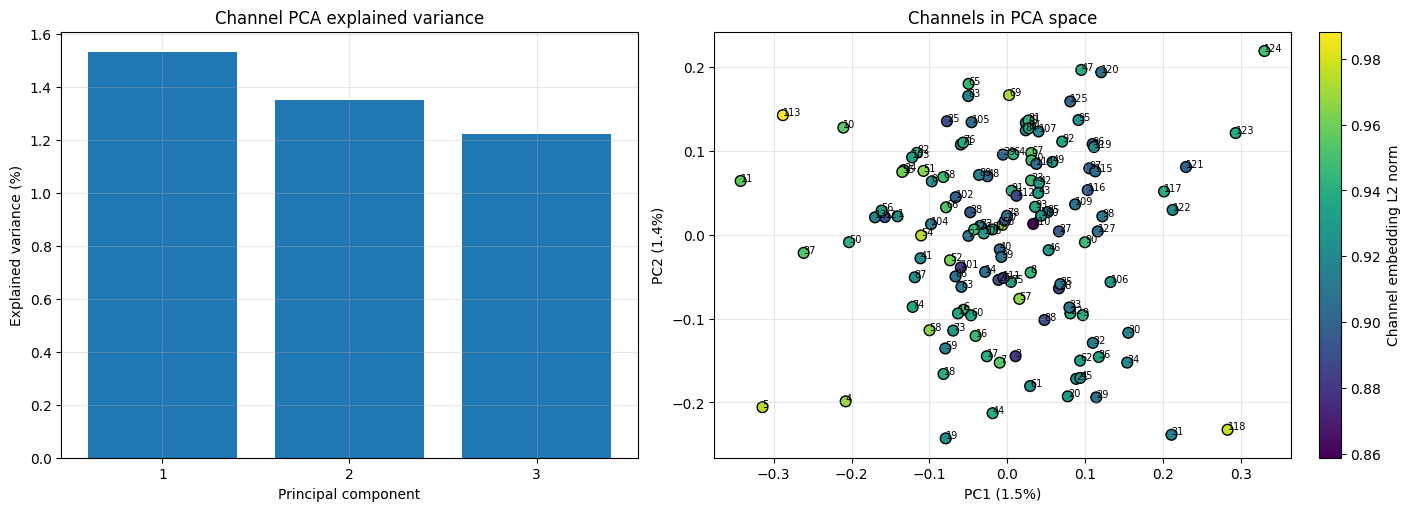

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].bar([1, 2, 3], explained_ratio * 100.0)
axes[0].set_xticks([1, 2, 3])
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Explained variance (%)')
axes[0].set_title('Channel PCA explained variance')
axes[0].grid(True, alpha=0.3)

sc = axes[1].scatter(
    channel_pca_df['pc1'],
    channel_pca_df['pc2'],
    c=channel_pca_df['l2_norm'],
    cmap='viridis',
    s=60,
    edgecolor='k',
)
for _, row in channel_pca_df.iterrows():
    axes[1].text(row['pc1'], row['pc2'], str(int(row['channel'])), fontsize=7)
axes[1].set_xlabel(f"PC1 ({explained_ratio[0] * 100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({explained_ratio[1] * 100:.1f}%)")
axes[1].set_title('Channels in PCA space')
axes[1].grid(True, alpha=0.3)
plt.colorbar(sc, ax=axes[1], label='Channel embedding L2 norm')

plt.show()

In [11]:
top_pc1_pos = channel_pca_df.sort_values('pc1', ascending=False).head(10)
top_pc1_neg = channel_pca_df.sort_values('pc1', ascending=True).head(10)
top_pc2_pos = channel_pca_df.sort_values('pc2', ascending=False).head(10)
top_pc2_neg = channel_pca_df.sort_values('pc2', ascending=True).head(10)

print('Top +PC1 channels:')
display(top_pc1_pos[['channel', 'pc1', 'pc2', 'l2_norm']])
print('Top -PC1 channels:')
display(top_pc1_neg[['channel', 'pc1', 'pc2', 'l2_norm']])
print('Top +PC2 channels:')
display(top_pc2_pos[['channel', 'pc1', 'pc2', 'l2_norm']])
print('Top -PC2 channels:')
display(top_pc2_neg[['channel', 'pc1', 'pc2', 'l2_norm']])

Top +PC1 channels:


,channel,pc1,pc2,l2_norm
124,124,0.330488,0.218804,0.949879
123,123,0.293521,0.121069,0.937604
118,118,0.283104,-0.232552,0.977573
121,121,0.229732,0.080569,0.899195
122,122,0.212574,0.029437,0.921660
31,31,0.211061,-0.238526,0.916330
117,117,0.201474,0.051412,0.937581
30,30,0.155558,-0.117038,0.917842
34,34,0.154163,-0.152527,0.921362
106,106,0.132757,-0.056497,0.929205


Top -PC1 channels:


,channel,pc1,pc2,l2_norm
11,11,-0.342496,0.063957,0.955814
5,5,-0.314422,-0.205671,0.974497
113,113,-0.288203,0.142382,0.988206
37,37,-0.261532,-0.021783,0.952899
10,10,-0.210560,0.127530,0.955221
4,4,-0.207541,-0.198698,0.968133
50,50,-0.203225,-0.009030,0.941934
13,13,-0.169863,0.020603,0.917936
56,56,-0.161497,0.028631,0.931300
12,12,-0.157284,0.020879,0.891607


Top +PC2 channels:


,channel,pc1,pc2,l2_norm
124,124,0.330488,0.218804,0.949879
47,47,0.095176,0.196277,0.939473
120,120,0.120763,0.193558,0.908255
65,65,-0.049605,0.179688,0.944638
69,69,0.002396,0.166227,0.970988
83,83,-0.050039,0.165140,0.915685
125,125,0.081073,0.158751,0.902260
113,113,-0.288203,0.142382,0.988206
95,95,0.091596,0.136562,0.926050
81,81,0.027356,0.136040,0.943157


Top -PC2 channels:


,channel,pc1,pc2,l2_norm
19,19,-0.078993,-0.242824,0.924796
31,31,0.211061,-0.238526,0.916330
118,118,0.283104,-0.232552,0.977573
44,44,-0.018737,-0.212840,0.939088
5,5,-0.314422,-0.205671,0.974497
4,4,-0.207541,-0.198698,0.968133
29,29,0.114426,-0.193965,0.907737
20,20,0.077806,-0.192824,0.929968
61,61,0.029445,-0.180515,0.925790
21,21,0.088577,-0.171925,0.926530


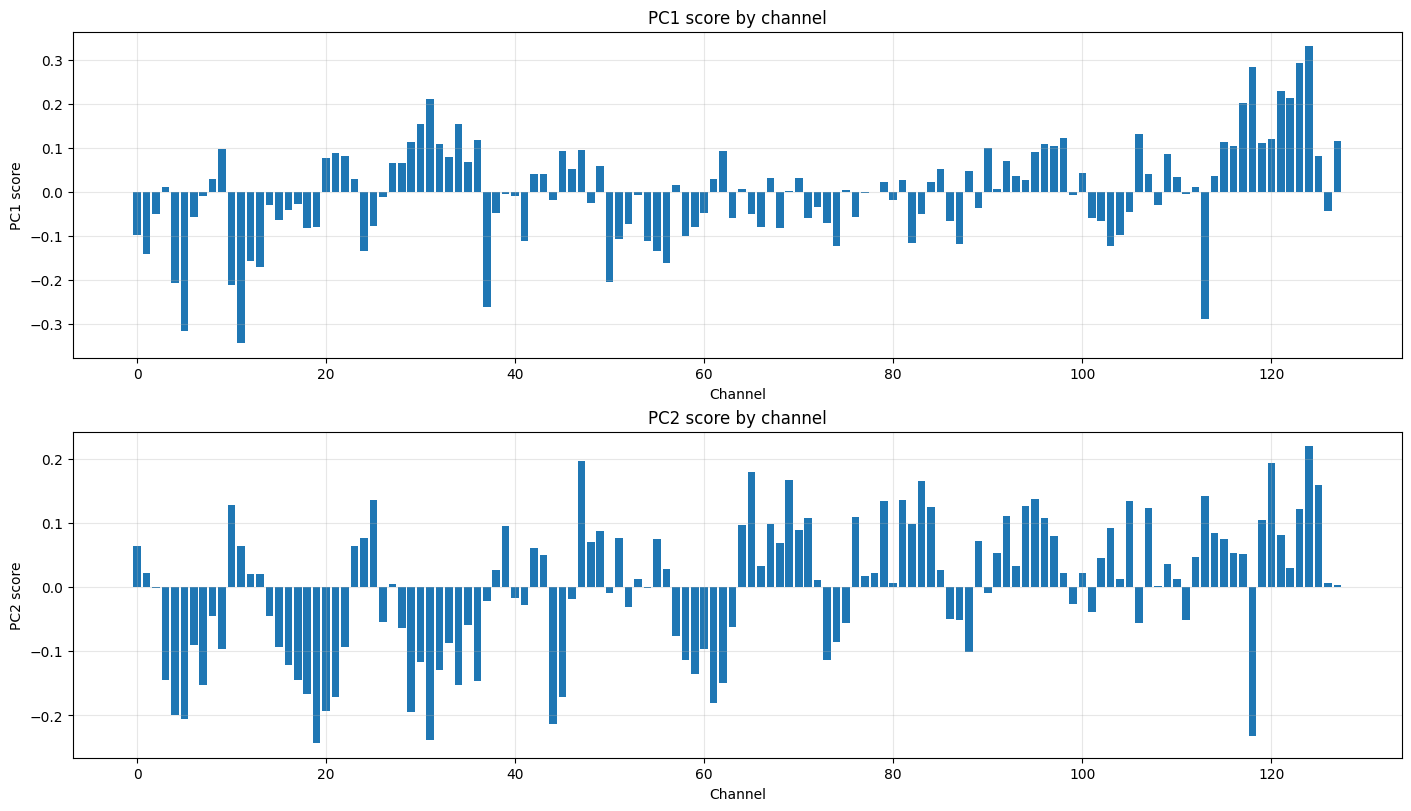

PC1 channel ordering (low → high):
[11, 5, 113, 37, 10, 4, 50, 13, 56, 12, 1, 55, 24, 103, 74, 87, 82, 41, 54, 51, 58, 104, 0, 68, 18, 59, 19, 66, 25, 52, 73, 86, 102, 15, 71, 101, 63, 76, 6, 83, 2, 65, 38, 60, 105, 126, 16, 89, 72, 108, 14, 17, 48, 80, 44, 26, 7, 40, 99, 53, 39, 111, 77, 78, 69, 75, 91, 64, 3, 112, 57, 84, 79, 81, 94, 61, 8, 23, 67, 70, 110, 93, 114, 43, 107, 42, 100, 88, 85, 46, 49, 27, 28, 35, 92, 20, 33, 125, 22, 109, 21, 95, 62, 45, 47, 9, 90, 116, 97, 96, 32, 119, 115, 29, 127, 36, 120, 98, 106, 34, 30, 117, 31, 122, 121, 118, 123, 124]
PC2 channel ordering (low → high):
[19, 31, 118, 44, 5, 4, 29, 20, 61, 21, 45, 18, 7, 34, 62, 36, 17, 3, 59, 32, 16, 30, 73, 58, 88, 60, 9, 15, 22, 6, 33, 74, 57, 28, 63, 35, 106, 75, 26, 111, 87, 86, 8, 14, 101, 52, 41, 99, 37, 46, 40, 90, 50, 2, 54, 108, 127, 27, 126, 80, 72, 53, 104, 110, 77, 13, 12, 98, 1, 78, 100, 38, 85, 56, 122, 66, 93, 109, 102, 112, 43, 117, 91, 116, 42, 0, 11, 23, 68, 48, 89, 55, 115, 51, 24, 97, 121, 11

In [8]:
pc1_order = channel_pca_df.sort_values('pc1')['channel'].to_numpy()
pc2_order = channel_pca_df.sort_values('pc2')['channel'].to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)
axes[0].bar(channel_pca_df['channel'], channel_pca_df['pc1'])
axes[0].set_title('PC1 score by channel')
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('PC1 score')
axes[0].grid(True, alpha=0.3)

axes[1].bar(channel_pca_df['channel'], channel_pca_df['pc2'])
axes[1].set_title('PC2 score by channel')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('PC2 score')
axes[1].grid(True, alpha=0.3)

plt.show()

print('PC1 channel ordering (low → high):')
print(pc1_order.tolist())
print('PC2 channel ordering (low → high):')
print(pc2_order.tolist())